# Download catalog files

In [3]:
! wget https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.csv.gz
! wget https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.columns.csv
#decompress the file
! gunzip dja_msaexp_emission_lines_v4.4.csv.gz

--2026-02-24 19:43:32--  https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.csv.gz
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.103.118, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133004545 (127M) [text/plain]
Saving to: ‘dja_msaexp_emission_lines_v4.4.csv.gz’

dja_msaexp_emission 100%[===================>] 126.84M  5.94MB/s    in 27s     

2026-02-24 19:43:59 (4.75 MB/s) - ‘dja_msaexp_emission_lines_v4.4.csv.gz’ saved [133004545/133004545]

--2026-02-24 19:43:59--  https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.columns.csv
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24746 (24K) [text/plain]
Saving to: ‘dja_msaexp_emission_lines_v4.4.columns.csv’

dja_

In [79]:
import pandas as pd
df = pd.read_csv("dja_msaexp_emission_lines_v4.4.csv")
df.head()

/var/folders/6h/pm731bh5769gqlt1mrys7wth0000gn/T/ipykernel_21641/2695337296.py:2: DtypeWarning: Columns (321,324,330,360,361) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dja_msaexp_emission_lines_v4.4.csv")


,file,srcid,ra,dec,grating,filter,effexptm,nfiles,dataset,msamet,...,beta_wlo,beta_whi,beta_nmad,dla_npix,dla_value,dla_unc,beta_cov_00,beta_cov_01,beta_cov_10,beta_cov_11
0,abell2744-castellano1-v4_prism-clear_3073_1400...,14008,3.497359,-30.358230,PRISM,CLEAR,2188.333,6,jw03073010001_03101_00001_nrs1_clear_prism_raw...,jw03073010001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,abell2744-castellano1-v4_prism-clear_3073_1403...,14033,3.493713,-30.360167,PRISM,CLEAR,2188.333,12,jw03073011001_03101_00001_nrs1_clear_prism_raw...,jw03073011001_01_msa.fits,...,0.141974,0.257962,0.863961,10.0,164.297141,48.081386,0.169414,-0.000296,-0.000296,0.000002
2,abell2744-castellano1-v4_prism-clear_3073_1413...,14130,3.498384,-30.358731,PRISM,CLEAR,2188.333,6,jw03073011001_03101_00001_nrs2_clear_prism_raw...,jw03073011001_01_msa.fits,...,0.221530,0.257772,1.150327,0.0,-1.000000,-1.000000,0.465769,-0.060752,-0.060752,0.008047
3,abell2744-castellano1-v4_prism-clear_3073_1418...,14182,3.497377,-30.359286,PRISM,CLEAR,2188.333,6,jw03073011001_03101_00001_nrs1_clear_prism_raw...,jw03073011001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,abell2744-castellano1-v4_prism-clear_3073_1426...,14269,3.497626,-30.359020,PRISM,CLEAR,2188.333,6,jw03073010001_03101_00001_nrs2_clear_prism_raw...,jw03073010001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


['CLEAR', 'F070LP', 'F100LP', 'F170LP', 'F290LP']
['G140H', 'G140M', 'G235H', 'G235M', 'G395H', 'G395M', 'PRISM']
1197


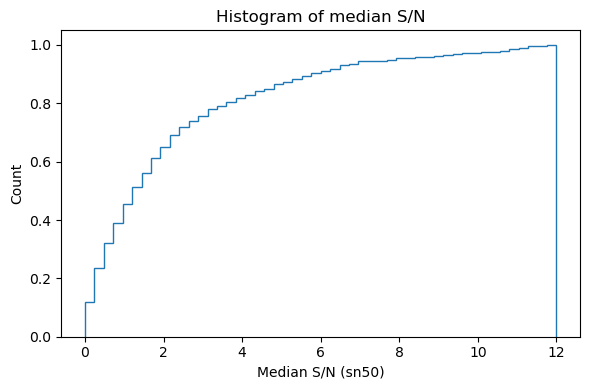

In [99]:
import matplotlib.pyplot as plt

mask = df['filter'].isin(["F100LP"]) & df['grade'].isin([1,2,3]) #& df['grating'].isin(["G140H"])
#min wavelength < 1.3 max wavelength > 1.7

sn_median = df["sn50"][mask].dropna()

plt.figure(figsize=(6,4))
plt.hist(sn_median, bins=50, histtype="step", color="C0", range=(0, 12), cumulative=True, density=True)
plt.xlabel("Median S/N (sn50)")
plt.ylabel("Count")
plt.title("Histogram of median S/N")
plt.tight_layout()

print(sorted(df["filter"].dropna().unique()))
print(sorted(df["grating"].dropna().unique()))
print(len(df[mask]))

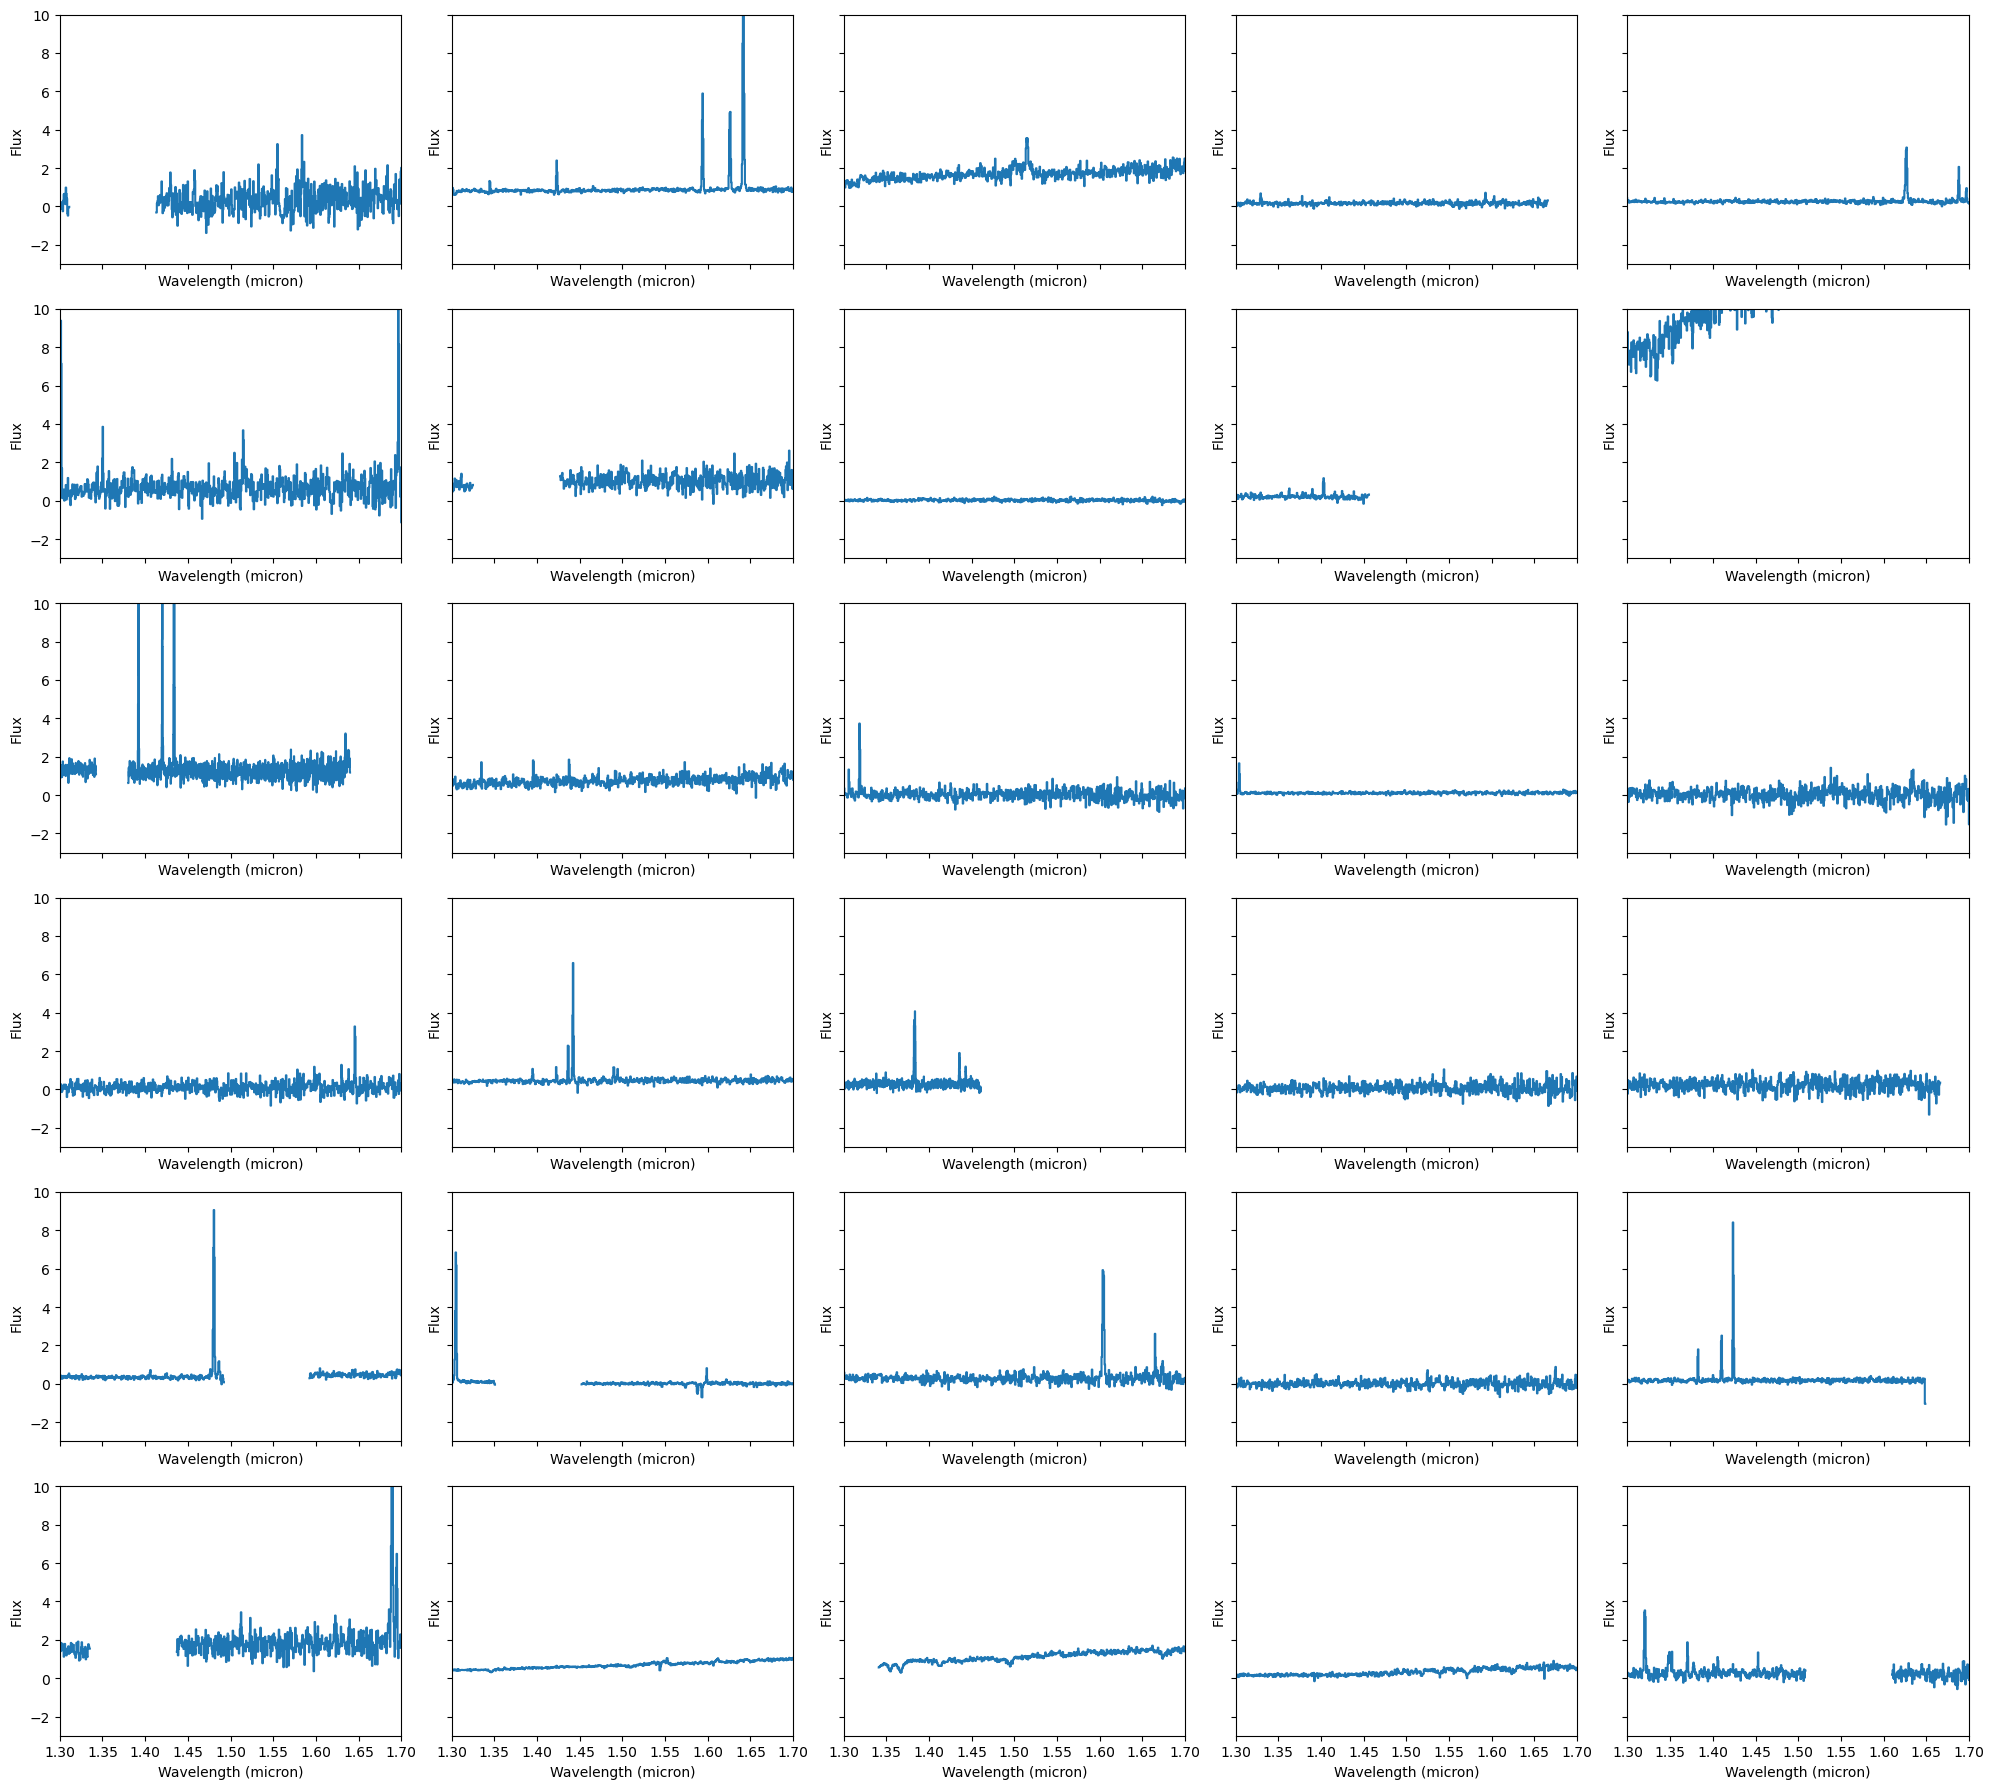

In [105]:
from astropy.utils.data import download_file
from astropy.table import Table
from tqdm.auto import tqdm
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

base_url = "https://s3.amazonaws.com/msaexp-nirspec/extractions"

download_dir = "download"

os.makedirs(download_dir, exist_ok=True)

# Select rows to download first (example: up to 500 rows)
download_df = df[mask].head(500).copy()

def download_one(row):
    url = f"{base_url}/{row['root']}/{row['file']}"  # file .spec.fits
    outname = os.path.join(download_dir, row["file"])
    if os.path.exists(outname):
        return outname
    try:
        tmp_fn = download_file(url, cache=False)
        os.rename(tmp_fn, outname)
        return outname
    except Exception as e:
        print(f"Failed: {url} -> {e}")
        return None

# Multi-threaded download
to_download = [row for _, row in download_df.iterrows()]

max_workers = 8  # Adjust thread count based on network conditions
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(download_one, row): row for row in to_download}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading spectra"):
        _ = fut.result()

# Randomly select n spectra and plot in a 5-column, multi-row subplot grid
n_spectra = 30  # You can modify how many spectra to display
n_cols = 5
n_rows = int(np.ceil(n_spectra / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)  # Flatten to 1D for easy iteration

sample_rows = df[mask].head(500).sample(n=min(n_spectra, mask.sum()), random_state=42)

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    spec_file = f"{download_dir}/{row['file']}"
    spec_tab = Table.read(spec_file)  # Auto-detect FITS
    ax.plot(spec_tab["wave"], spec_tab["flux"], drawstyle="steps-mid")
    ax.set_xlim(1.3, 1.7)
    ax.set_ylim(-3,10)
    ax.set_xlabel("Wavelength (micron)")
    ax.set_ylabel("Flux")

# Hide any unused subplot axes
for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [106]:
spec_file = f"{download_dir}/{df[mask].head(1)['file'].iloc[0]}"
spec_tab = Table.read(spec_file)
spec_tab["flux"].unit, spec_tab["wave"].unit


(Unit("uJy"), Unit("um"))